In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Proj, transform

In [4]:
# Load city boundary shapefile
file_path = "city boundary.shp"
city_boundary_gdf = gpd.read_file(file_path)

In [5]:
# regions_gdf.boundary

2020-2022 NAD83 / MTM zone 10: EPSG:2952

2011-2018 NAD27 / MTM zone 10: EPSG:2019

In [17]:
def image_check(df, crs, boundary, year):
    regions_gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['Boundary']), crs=crs) 

    # Transform regions to WGS 84 to match city boundary
    regions_gdf = regions_gdf.to_crs('EPSG:4326')
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 12))
    boundary.boundary.plot(ax=ax, color="blue", label='City Boundary')
    regions_gdf.boundary.plot(ax=ax, color="green", alpha=0.5, label='Regions Coverage')
    
    # Set plot title and labels
    ax.set_title(f'Toronto Coverage Map {year}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    plt.savefig('my_map.png') 
    # Show plot
    plt.show()

    return None

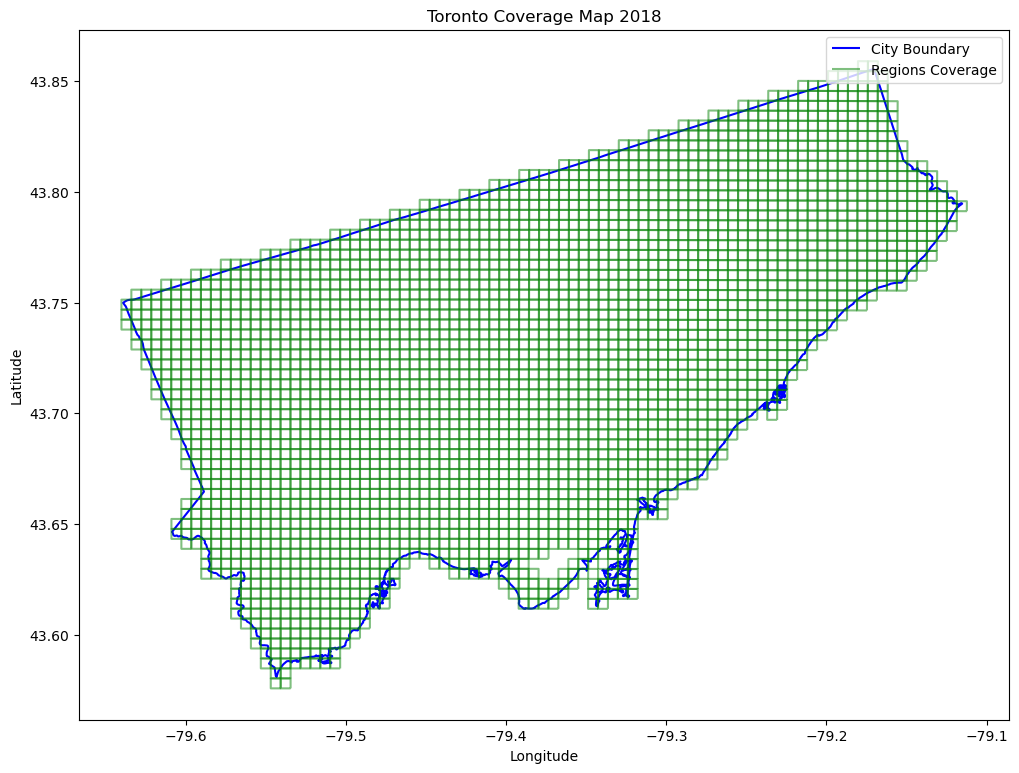

In [18]:
year = 2018
file = f'C:/Users/Lenovo/Desktop/python/ra/Solar-Panel/data/images_check/{year}_image_check.xlsx'
df = pd.read_excel(file)
image_check(df, 'EPSG:2019', city_boundary_gdf, year)

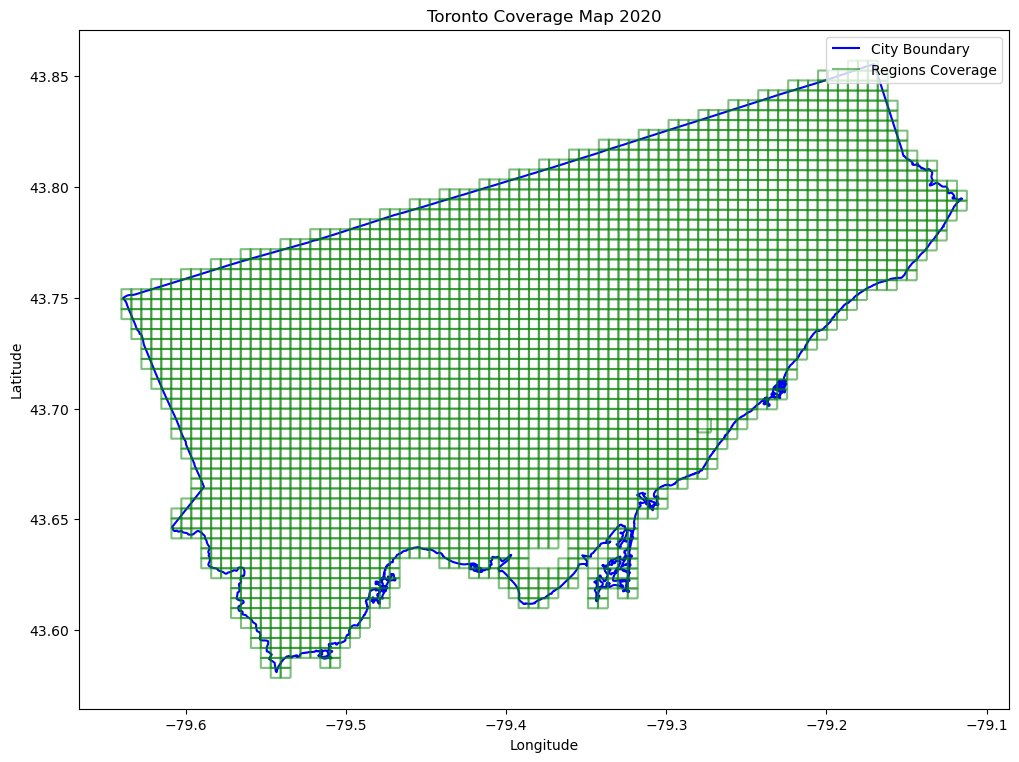

In [19]:
year = 2020
file = f'C:/Users/Lenovo/Desktop/python/ra/Solar-Panel/data/images_check/{year}_image_check.xlsx'
df = pd.read_excel(file)
image_check(df, 'EPSG:2952', city_boundary_gdf, year)